In [1]:
import pandas as pd

In [23]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
pd.set_option("display.max_columns", None)

In [5]:
df=pd.read_excel("Dataset for Data Analytics.xlsx")

In [6]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [7]:
df.shape

(1200, 14)

In [8]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [9]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [11]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [12]:
(df.isnull().sum()/len(df))*100

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['OrderID'].duplicated().sum()

np.int64(0)

In [15]:
df=df.drop_duplicates(subset='OrderID',keep='first')

In [16]:
for col in df.select_dtypes(include=['string']).columns:
    df[col]=df[col].str.strip()

In [17]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')

In [18]:
text_columns=[
    'Product',
    'PaymentMethod',
    'OrderStatus',
    'ReferralSource'
]
for col in text_columns:
    df[col]=df[col].str.title()
    


In [19]:
df['CouponCode']=df['CouponCode'].fillna('No Coupon')

In [20]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [21]:
for col in df.columns:
    print("\ncolumn:",col)
    print("unique value:",df[col].nunique())


column: OrderID
unique value: 1200

column: Date
unique value: 671

column: CustomerID
unique value: 1189

column: Product
unique value: 7

column: Quantity
unique value: 5

column: UnitPrice
unique value: 1193

column: ShippingAddress
unique value: 655

column: PaymentMethod
unique value: 5

column: OrderStatus
unique value: 5

column: TrackingNumber
unique value: 1200

column: ItemsInCart
unique value: 10

column: CouponCode
unique value: 4

column: ReferralSource
unique value: 5

column: TotalPrice
unique value: 1195


In [24]:
for col in df.select_dtypes(include=["object"]).columns:
    print("\ncolumns:", col)
    print(df[col].nunique())


columns: OrderID
1200

columns: CustomerID
1189

columns: Product
7

columns: ShippingAddress
655

columns: PaymentMethod
5

columns: OrderStatus
5

columns: TrackingNumber
1200

columns: CouponCode
4

columns: ReferralSource
5


In [25]:
df.mean(numeric_only=True)

Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64

In [26]:
df.mean(numeric_only=True)

Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64

In [27]:
df.count()

OrderID            1200
Date               1200
CustomerID         1200
Product            1200
Quantity           1200
UnitPrice          1200
ShippingAddress    1200
PaymentMethod      1200
OrderStatus        1200
TrackingNumber     1200
ItemsInCart        1200
CouponCode         1200
ReferralSource     1200
TotalPrice         1200
dtype: int64

In [29]:
product_sales=df['Product'].value_counts()
print(product_sales)

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


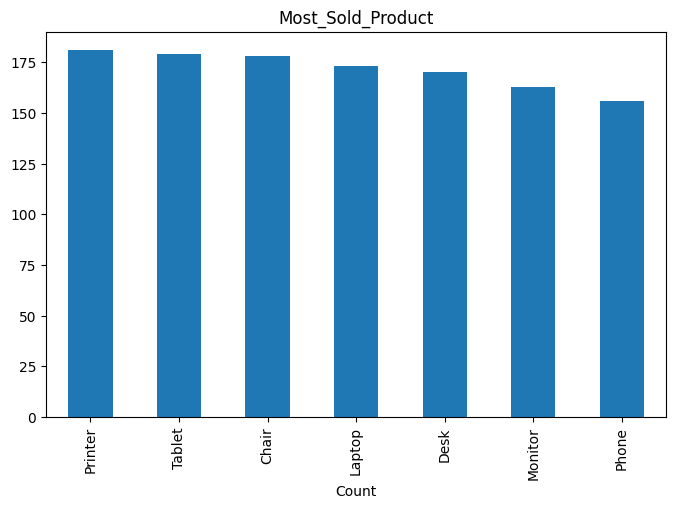

In [30]:
plt.figure(figsize=(8,5))
product_sales.plot(kind='bar')
plt.title('Most_Sold_Product')
plt.xlabel('Product')
plt.xlabel('Count')
plt.show()

In [31]:
revenue=df.groupby('Product')['TotalPrice'].sum()
print(revenue)

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64


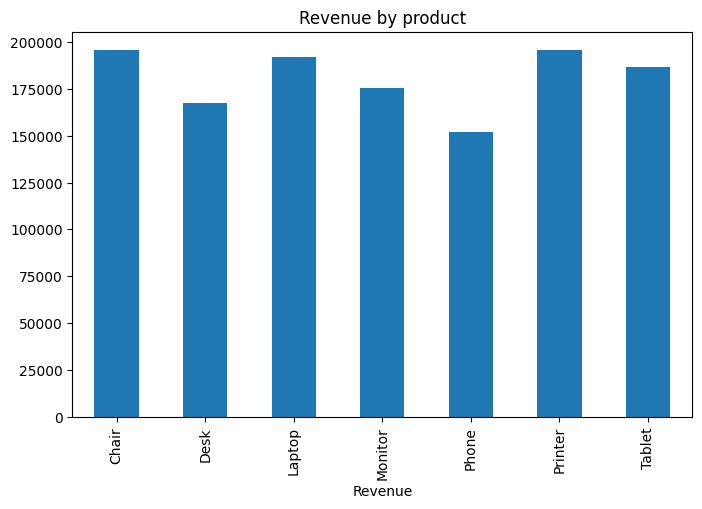

In [32]:
plt.figure(figsize=(8,5))
revenue.plot(kind='bar')
plt.title('Revenue by product')
plt.xlabel('Product')
plt.xlabel('Revenue')
plt.show()

In [34]:
payment_method=df['PaymentMethod'].value_counts()
print(payment_method)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


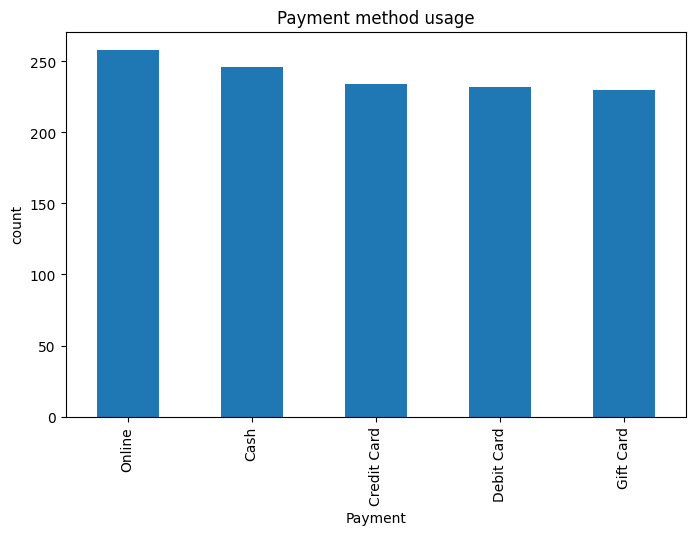

In [44]:
plt.figure(figsize=(8,5))
payment_method.plot(kind='bar')
plt.title('Payment method usage')
plt.xlabel('Payment')
plt.ylabel('count')
plt.show()

In [36]:
order_status=df['OrderStatus'].value_counts()
print(order_status)

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


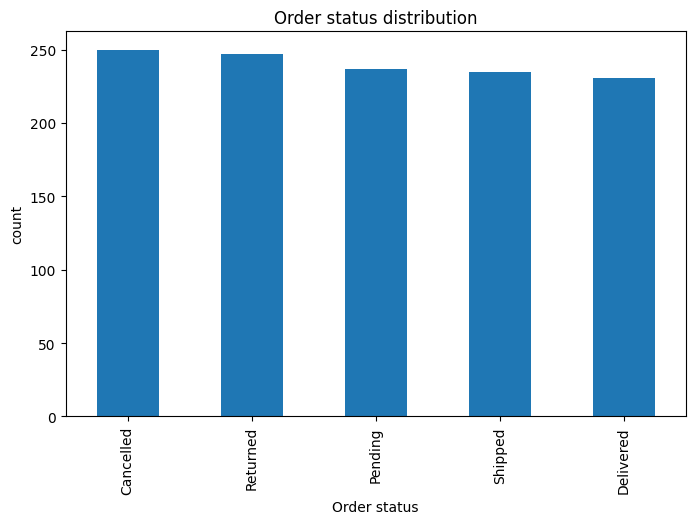

In [43]:
plt.figure(figsize=(8,5))
order_status.plot(kind='bar')
plt.title('Order status distribution')
plt.xlabel('Order status')
plt.ylabel('count')
plt.show()

In [38]:
orders_by_date=df.groupby('Date').size()
print(orders_by_date.head())

Date
2023-01-01    3
2023-01-02    2
2023-01-03    1
2023-01-04    2
2023-01-05    2
dtype: int64


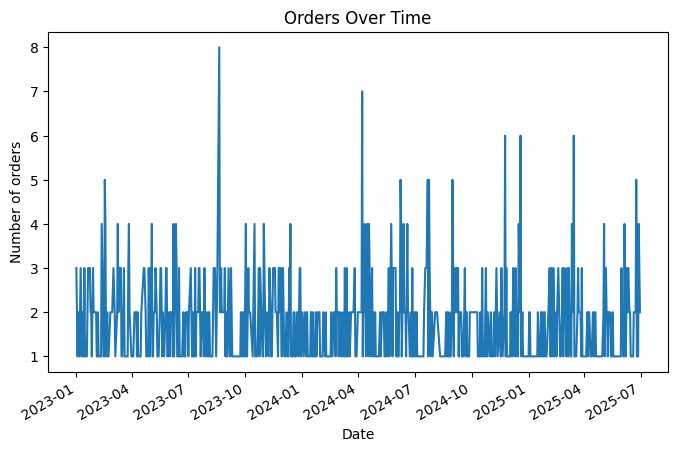

In [42]:
plt.figure(figsize=(8,5))
orders_by_date.plot()
plt.title('Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Number of orders')
plt.show()

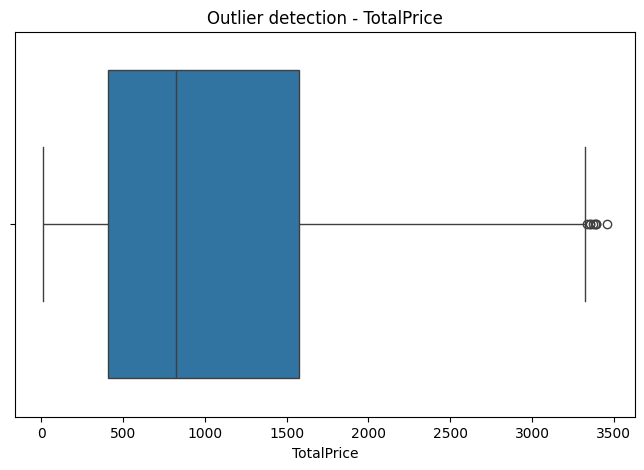

In [45]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(x=df['TotalPrice'])
plt.title("Outlier detection - TotalPrice")
plt.show()


In [52]:
correlation=df.corr(numeric_only=True)
print(corelation)

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


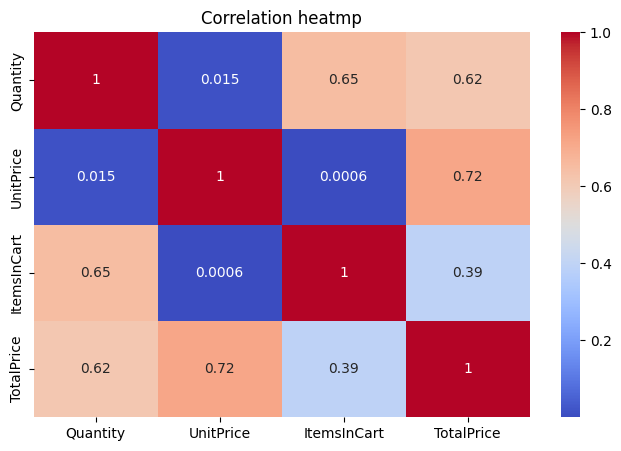

In [54]:
plt.figure(figsize=(8,5))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation heatmp")
plt.show()

In [56]:
print("most_sold_product:",product_sales.idxmax())

most_sold_product: Printer


In [57]:
print("Highest_revenue_product:",revenue.idxmax())

Highest_revenue_product: Chair


In [58]:
print("Most_used_payment_method:",payment_method.idxmax())

Most_used_payment_method: Online


In [59]:
print("Most_common_order_status:",order_status.idxmax())

Most_common_order_status: Cancelled


In [60]:
df.to_excel('EDA_Processed_Data.xlsx',index=False)

In [61]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
